![FOCCUS_logo](imgs/FOCCUS_LOGO.jpg "logo")
# FOCCUS Demonstrator: Multi-Use Impact in the southern North Sea

### **Objective and Background** 

The objective of this demonstrator is to showcase the results from Application 2.2.1.3 in [D8.1](https://zenodo.org/records/17064233 "D8.1")

**The goal of the application** is to assess the impact of **multi-use** on water quality and stratification in the Southern North Sea. By comparing model runs with offshore wind farms and aquaculture to model runs without any additions (a base case), we can dissect what changes in the environment due to the multi-use impacts. With this, the application assesses the changes in typical stratification variables and water quality variables due to the addition of offshore wind farms and/or aquaculture. 


### What is Multi-Use? 

<details>
<summary>  Click for more </summary>

Offshore wind multi-use (hereafter referred to as multi-use) is the intentional sharing of ocean space and infrastructure by multiple sectors (such as energy and aquaculture). In this application, multi-use represents the joint use of wind turbines and surroundings to grow mussels for commercial use. These activities benefit from each other, as they share the same space and wind turbines offer anchor points for the mussel cultivation. 

The figure below depicts how mussels are suspended in and near the wind turbines.



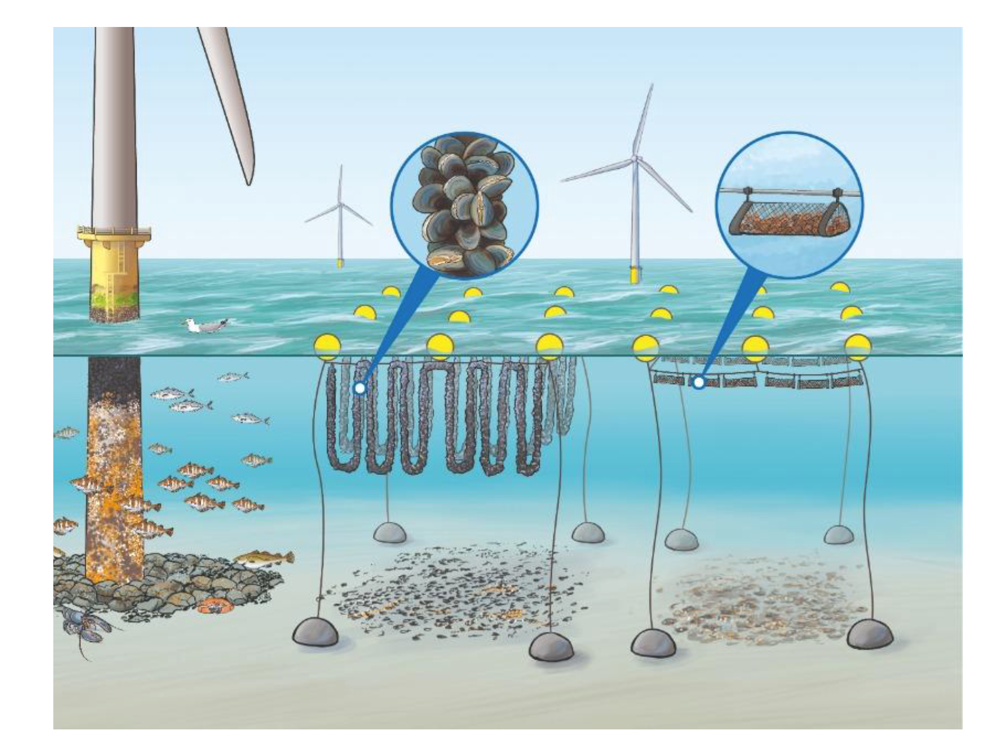 @Hendrik Gheerardyn (2022)


</details>





### **This notebook is structured as follows:**

1. Location and lyaout of the offshore wind farms
2. Overview of the Aquaculture Sites 
3. Overview of base case scenario variables.
4. Comparison tool to explore the changes in variables between scenarios.
7. How was this application made, and where to find more information.

# 1. Location and layout of the offshore wind farms

In the application, we specify the location and structure of the wind farms with hypothetical upscaling scenario, based on the outlook of the industry for roughly 
2050. This scenario includes current and future planned offshore wind farms. Locations of offshore wind farms are specified in the application through a polygon along its boundaries.  Within this polygon, the hydrodynamics are affected, as well as the wind speed, which is reduced by 10%. 

To see which wind farms were used in this application, run the following block of code! 

In [1]:
#imports 
import ipywidgets as widgets
from IPython.display import display, clear_output

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import cartopy.io.shapereader as shpreader
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
import xarray as xr
import xugrid as xu
import warnings



In [2]:

# --- Load OWF scenario ---
shp_path = 'data/Scenario_2050.shp'
reader = shpreader.Reader(shp_path)
geometries = list(reader.geometries())


# --- Plot function ---
def plot_map_int(xmin, xmax, ymin, ymax):
    fig = plt.figure(figsize=(8, 7), dpi=150)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Background
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor="#fff7bc")
    ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor="#c6dbef")
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.2)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=":")

    # shapefile
    ax.add_geometries(
        geometries,
        crs=ccrs.PlateCarree(),
        edgecolor="red",
        facecolor="grey",
        linewidth=0.5
    )

    # extent from sliders 
    ax.set_extent([xmin, xmax, ymin, ymax], crs=ccrs.Geodetic())
    ax.set_aspect('auto')

    plt.title('Offshore wind farm Scenario')
    plt.show()


# --- Output area ---
out = widgets.Output()


# --- Sliders ---
xmin_slider = widgets.FloatSlider(value=-4, min=-10, max=10, step=0.1, description="xmin")
xmax_slider = widgets.FloatSlider(value=9,  min=-10, max=10, step=0.1, description="xmax")
ymin_slider = widgets.FloatSlider(value=50, min=45, max=65, step=0.1, description="ymin")
ymax_slider = widgets.FloatSlider(value=60, min=45, max=65, step=0.1, description="ymax")


# --- Update function ---
def update(change=None):
    with out:
        clear_output(wait=True)
        plot_map_int(
            xmin_slider.value,
            xmax_slider.value,
            ymin_slider.value,
            ymax_slider.value
        )


# trigger on slider change
xmin_slider.observe(update, names="value")
xmax_slider.observe(update, names="value")
ymin_slider.observe(update, names="value")
ymax_slider.observe(update, names="value")


# layout
controls = widgets.VBox([
    widgets.HBox([xmin_slider, xmax_slider]),
    widgets.HBox([ymin_slider, ymax_slider])
])

display(controls, out)

# initial plot
update()

Output()

# 2. Location of aquaculture sites 

In the application, we specify the location and structure of the aquaculture sites based on a suitability assessment that was executes for the Dutch EEZ before. In this case, we are considering all sites that show high suitability in the long term (untill 2050) (Steenbergen et al., 2023). You might not notice that not all aquaculture sites directly correlate to an offshore wind farm location. This is because aquaculture can also be practiced in the vicinity of the wind farms, where conditions are sometimes even more optimal. 

*The model setup for aquaculture implements  model changes developed within other Horizon Europe Projects,  EDITO-Model Lab and ULTFARMS*
<details>
<summary>  Full reference</summary>

Steenbergen, J., van Hal, R., Kamermans, P., Nauta, R., Schneider, L., Vallina, T., Heye, S., & van Duren, L. (2023). Kansrijke windenergiegebieden voor maricultuur en passieve visserij: Kwalitatieve beoordeling van de geschiktheid van de bestaande, geplande en nog aan te wijzen windenergiegebieden voor zeewierkweek, schelpdierkweek en passieve visserij als medegebruiksfunctie. (Wageningen Marine Research rapport; No. C015/23). Wageningen Marine Research. https://doi.org/10.18174/629189


</details>


In [3]:

shp1 = "data/AQ_Msetup.shp"
shp2 = "data/Scenario_2050.shp"

def plot_maps(shp1, title, shp2=None):
    fig = plt.figure(figsize=(8, 7), dpi=150)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # --- Background ---
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor="#fff7bc", zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor="#c6dbef", zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.5, zorder=1)
    ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=":", zorder=1)

    # --- shp2 (OWF) ---
    if shp2 is not None:
        reader2 = shpreader.Reader(shp2)
        geometries2 = list(reader2.geometries())

        ax.add_geometries(
            geometries2,
            crs=ccrs.PlateCarree(),
            facecolor="grey",
            edgecolor="black",
            linewidth=0.7,
            alpha=0.6,
            zorder=2   
        )

    # --- shp1 (AQ layer)---
    reader1 = shpreader.Reader(shp1)
    geometries1 = list(reader1.geometries())

    ax.add_geometries(
        geometries1,
        crs=ccrs.PlateCarree(),
        facecolor="green",
        edgecolor="black",
        linewidth=0.7,
        zorder=3  
    )

    # --- extent ---
    ax.set_extent([2, 8, 51, 55], crs=ccrs.Geodetic())
    ax.set_aspect('auto')

    plt.title(title)
    plt.show()




# --- Widget ---
out2 = widgets.Output()

dropdown = widgets.Dropdown(
    options=[
        ("Aquaculture Only", ("Aquaculture Only", None)),
        ("Aquaculture and OWF", ("Aquaculture and OWF", shp2))
    ],
    description="Select map:"
)


def update(change):
    with out2:
        clear_output(wait=True)
        
        title, shp2_val = change["new"]
        plot_maps(shp1, title, shp2_val)



dropdown.observe(update, names="value")

# display both
display(dropdown, out2)

# initial plot
with out2:
    title, shp2_val = dropdown.value
    plot_maps(shp1, title, shp2_val)



Dropdown(description='Select map:', options=(('Aquaculture Only', ('Aquaculture Only', None)), ('Aquaculture a…

Output()

# 3. Introduction to Impacted Variables & explore them for the Reference Scenario 

This section introduces the variables that are used to characterize the impact of offshore wind farms and aquaculture. 

The following variables can be explored for the Southern North Sea: 

### Ocean Physics 

1. #### *temp_strat* --  **Temperature Stratificiation (summer):** 

   This variable resembles the difference in temperature with depth, and can be used as a proxy for the stratification of the vertical dimension.
   Therefore, it is calculated by subtracting the annual mean value in the bottom model layer from that in the surface model layer.

2. #### *temp_surface* --  **Sea Surface Temperature (summer):**

   This variable resembles the sea surface temperature in summer.

3.  #### *temp_bottom* --  **Near-bed Temperature (summer):**

    This variable resembles the near bed temperature in summer. 

4. #### *bed_shear_stress* -- **Bed Shear Stress (yearly mean)**

   This variable resembles the shear stress at the bottom, due to differences in turbulence and waves near the wind farms.

5. #### *significant_wave_height* -- **Significant wave height (yearly mean)**

   This variable resembles the significant wave height, reflecting the differences in wave propagation due to the offshore structures. 

### Water Quality 
1. #### *TotN* -- **Total Nitrogen (growing season surface mean):**

   This variable resembles the winter season mean estimated total nitrogen at the surface. Variations in stratification & flow cause differences in the spread of nutrients.

2. #### *TotP* -- **Total Phosphorus (growing season surface mean):**

   This variable resembles the winter season mean estimated total phosphorus at the surface. Variations in stratification & flow cause differences in the spread of nutrients.  

3. #### *Chlorophyll* -- **Surface Chlorophyll-a (growing season mean):**

   This variable resembles the growing season mean of Chlorophyll-a at the surface. Variation in stratification, flow and nutrients results in differences in the number of algae, thereby causing differences in chlorophyll-a.

4.  #### *Primary_production* -- **Primary Production, depth averaged(growing season mean):**
    This variable resembles the growing season, depth averaged primary production. Variation in stratification, flow and nutrients results in differences in the number of algae, thereby causing differences in the primary   production. 


In [ ]:
from download_from_s3 import download_nc_files_from_s3

# download outputs
download_nc_files_from_s3(
    files_to_download=['REF_4nm_2013_wv.nc', 'OWF_4nm_2013_wv.nc','AQ_4nm_2013_wv.nc'],
    s3_subfolder="Deltares",
    local_output_dir=fr"data"
)
print("✅ Download complete.")

In [ ]:
#load in the Reference scenario dataset, and iterate over 

warnings.filterwarnings(
    "ignore",
    message="The following grid mapping variable is specified",
    category=UserWarning
)
# ---- load dataset ----
path = r"data/REF_4nm_2013_wv.nc"
ds = xu.open_dataset(path)

# ---- plotting settings ----
plot_settings = {
    "temp_surface": {"cmap": "viridis", "vmin": 0, "vmax": 18},
    "temp_bottom": {"cmap": "viridis", "vmin": 0, "vmax": 18},
    "temp_strat": {"cmap": "RdBu_r", "vmin": -3, "vmax": 3},
    "bed_shear_stress": {"cmap": "viridis", "vmin": 0, "vmax": 1.5},
    "chlorophyll": {"cmap": "Greens", "vmin": 0, "vmax": 10},
    "TotN": {"cmap": "plasma", "vmin": 0, "vmax": 2},
    "TotP": {"cmap": "plasma", "vmin": 0, "vmax": 0.1},
    "significant_wave_height": {"cmap": "plasma", "vmin": 0, "vmax": 5},
    "TIM": {"cmap": "plasma", "vmin": 0, "vmax": 30}
}

default_plot = {"cmap": "viridis", "vmin": None, "vmax": None}


def plot_var(var):
    s = plot_settings.get(var, default_plot)

    fig = plt.figure(figsize=(13, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="#fff7bc", zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8,zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5,zorder=3)
    ax.set_aspect('auto')
    pcm = ds[var].ugrid.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=s["cmap"],
        vmin=s["vmin"],
        vmax=s["vmax"],
        add_colorbar=False,   # key change
        rasterized=True,zorder=0,
    )

    ax.set_extent([0, 9, 51, 57],crs=ccrs.PlateCarree())

    cbar = plt.colorbar(pcm, ax=ax, shrink=0.8)
    
    long_name = ds[var].attrs.get("long_name", var)
    units = ds[var].attrs.get("units", "")
    
    label = f"{long_name} ({units})" if units else long_name
    
    cbar.set_label(label)

    plt.title(var)
    plt.show()



# ---- widgets ----
dropdown = widgets.Dropdown(options=list(ds.data_vars), description="Variable:")


widgets.interactive(
    plot_var,
    var=dropdown,
)

interactive(children=(Dropdown(description='Variable:', options=('temp_strat', 'temp_surface', 'temp_bottom', …

# 4. Comparison tool to explore the changes in variables between scenarios.

With the following block, you can compare the different scenarios for all variables. You can explore how variables change between the three scenarios, using the percentage difference between the scenario and reference. 

To show the different effects, use the following settings: 


- #### Impact of Offshore wind farms:
  **Scenario**: OWF

  **Reference** : REF
  
- #### Impact of Aquaculture:
  **Scenario**: OWF+AQ

  
  **Reference**: OWF

  
- #### Impact of Multi-Use (OWF and AQ):
  **Scenario**: OWQ+AQ

  
  **Reference**: REF

To aid visualization, you can choose to turn on the outlines of the offshore wind farms and aquaculture sites. 

![Scenario_Setup](imgs/ScenarioSetup.png "Scenario")

In [8]:
paths = {
    "REF": r"data/REF_4nm_2013_wv.nc",
    "OWF": r"data/OWF_4nm_2013_wv.nc",
    "OWF+AQ": r"data/AQ_4nm_2013_wv.nc"
}

datasets = {
    name: xu.open_dataset(path.strip())
    for name, path in paths.items()
}

# Assume all datasets have the same variables
variables = list(next(iter(datasets.values())).data_vars)

# ---- paths to shapefiles ----
shp2_path = r"data/AQ_Msetup.shp"
shp1_path = r"data/Scenario_2050.shp"

# Preload geometries
geoms1 = list(shpreader.Reader(shp1_path).geometries())
geoms2 = list(shpreader.Reader(shp2_path).geometries())

# ---- widgets ----
reference_dropdown = widgets.Dropdown(options=list(datasets.keys()),value="REF",description="Reference:")

dsA_dropdown = widgets.Dropdown(options=list(datasets.keys()), value="OWF" if "OWF" in datasets else list(datasets.keys())[0], description="Scenario:")

var_dropdown = widgets.Dropdown(options=variables,description="Variable:")

plot_button = widgets.Button(description="Plot % difference",button_style="primary",icon="play")

shp2_toggle = widgets.Checkbox(value=False,description="Show Aquaculture Sites")

shp1_toggle = widgets.Checkbox(value=False,description="Show OWF locations")

status = widgets.HTML(value="")
output = widgets.Output()

# ---- plotting settings for absolute differences ----
plot_settings_diff = {
    "temp_strat": {
        "cmap": "RdBu_r",
        "vmin": -1,
        "vmax": 1
    },
    "bed_shear_stress": {
        "cmap": "RdBu_r",
        "vmin": -0.05,
        "vmax": 0.05
    },
    "chlorophyll": {
        "cmap": "RdBu_r",
        "vmin": -1,
        "vmax": 1
    },
    "TotN": {
        "cmap": "RdBu_r",
        "vmin": -0.05,
        "vmax": 0.05
    },
    "TotP": {
        "cmap": "RdBu_r",
        "vmin": -0.001,
        "vmax": 0.001
    },
    "TIM": {
        "cmap": "RdBu_r",
        "vmin": -2,
        "vmax": 2
    },
    "significant_wave_height": {
        "cmap": "RdBu_r",
        "vmin": -0.3,
        "vmax": 0.3
    },
      "primary_production": {
        "cmap": "RdBu_r",
        "vmin": -0.1,
        "vmax": 0.1
}}

plot_button = widgets.Button(description="Plot difference",button_style="primary",icon="play")


# ---- plotting function ----
def plot_diff(_, show_shp1, show_shp2):
    with output:
        clear_output(wait=True)
        status.value = "⏳ Plotting..."

        scenario_name = dsA_dropdown.value
        scenario_ds = datasets[scenario_name]

        reference_name = reference_dropdown.value
        reference_ds = datasets[reference_name]

        var = var_dropdown.value

        scenario = scenario_ds[var]
        reference = reference_ds[var]

        # Absolute difference
        abs_diff = scenario - reference

        long_name = scenario.attrs.get("long_name", var)
        units = scenario.attrs.get("units", "")

        abs_diff.attrs["long_name"] = (
            f"{long_name} difference from {reference_name}"
        )
        abs_diff.attrs["units"] = units

        # ---- apply plot settings if available ----
        if var in plot_settings_diff:
            cmap = plot_settings_diff[var]["cmap"]
            vmin = plot_settings_diff[var]["vmin"]
            vmax = plot_settings_diff[var]["vmax"]

        else:
            max_abs_diff = np.nanmax(np.abs(abs_diff.values))

            if not np.isfinite(max_abs_diff) or max_abs_diff == 0:
                max_abs_diff = 1.0

            vmax = float(max_abs_diff)
            vmin = -vmax
            cmap = "RdBu_r"

        fig = plt.figure(figsize=(13, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())

        ax.add_feature(
            cfeature.LAND,
            facecolor="#fff7bc",
            zorder=1
        )
        ax.add_feature(
            cfeature.COASTLINE,
            linewidth=0.8,
            zorder=2
        )
        ax.add_feature(
            cfeature.BORDERS,
            linewidth=0.5,
            zorder=2
        )

        ax.set_aspect("auto")

        pcm = abs_diff.ugrid.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
            zorder=0,
            rasterized=True
        )

        ax.set_extent(
            [0, 9, 51, 57],
            crs=ccrs.PlateCarree()
        )

        # ---- shapefile overlays ----
        if show_shp1:
            ax.add_geometries(geoms1,crs=ccrs.PlateCarree(),facecolor="none",edgecolor="black",linewidth=0.6,zorder=5)

        if show_shp2:
            ax.add_geometries(geoms2,crs=ccrs.PlateCarree(),facecolor="none",edgecolor="green",linewidth=0.6,zorder=6)

        # ---- colorbar ----
        cbar = plt.colorbar(pcm,ax=ax,shrink=0.8)

        cbar.set_label(f"{long_name} difference ({scenario_name} - {reference_name}) [{units}]")

        # ---- gridlines ----
        gl = ax.gridlines(draw_labels=True,linewidth=0.3,alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False

        plt.title(f"{var} difference: {scenario_name} - {reference_name}")

        plt.show()

        status.value = "<b style='color:green'>Done</b>"


# ---- connect button ----
plot_button.on_click(lambda b: plot_diff( b,shp1_toggle.value,shp2_toggle.value))


# ---- layout ----
ui = widgets.VBox([widgets.HBox([reference_dropdown, dsA_dropdown]),
    var_dropdown,widgets.HBox([shp1_toggle,shp2_toggle]),
    plot_button,
    status,
    output
])

display(ui)

## How was this application made and more information 

run the following block to explore the schematic dataflow which describes the application input, software, output, validation, further processing and end products. 

add some more links to all zenodo documentation and other relevant documentaiton that there is 

In [6]:
from IPython.display import IFrame
IFrame("imgs/DF213.pdf", width=1700, height=1000)